# Review suspicious cell-tracking events

A Biohub submission is a **cell lineage graph**. This notebook turns that graph into a compact review queue: possible divisions, unusually long links, fragmented movies, low-link-density movies, and midpoint-like nodes that may have been inserted to bridge a missed detection.

It is written for competition participants who already have a `submission.csv`. No internet, model weights, or private inputs are required. If the competition OME-Zarr movies are attached, the review queue also becomes an image-based crop viewer; otherwise every graph diagnostic and coordinate-only plot still runs.

**You will learn how to:**

1. read and validate node and edge rows;
2. rank graph patterns worth inspecting;
3. compare suspicious-event counts across submissions;
4. view an event over nearby frames; and
5. replace the example with your own submission.

> These are review heuristics, not ground-truth error labels. A long link or a small component can be biologically correct.

## 1. Configuration

Set `SUBMISSION_PATH` to the CSV you want to review. Leaving it as `None` searches attached Kaggle inputs for files named `submission.csv`, then uses a local development fallback if this repository is available. Add paths to `COMPARE_PATHS` to compare several submissions.

Distances are computed in physical micrometres using the competition voxel spacing. The defaults deliberately produce a short, ranked queue rather than dumping every edge.

In [1]:
from __future__ import annotations

import json
import math
from collections import defaultdict
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# --- User configuration -------------------------------------------------
SUBMISSION_PATH = None  # e.g. "/kaggle/input/my-tracker-output/submission.csv"
COMPARE_PATHS = []      # optional additional submission.csv paths
MAX_AUTO_SUBMISSIONS = 3

LONG_EDGE_MIN_UM = 8.0
LONG_EDGE_QUANTILE = 0.99
MAX_EVENTS_PER_TYPE_PER_DATASET = 12
FRAGMENT_COMPONENTS_PER_100_NODES = 12.0
LOW_EDGE_TO_NODE_RATIO = 0.85
GAP_INTERPOLATION_MAX_RESIDUAL_UM = 0.75

EVENT_TYPE_TO_PLOT = "division"  # division, long_edge, gap_like, fragmentation, low_edge_ratio
EVENT_RANK = 0
CROP_RADIUS_XY = 64
FRAME_OFFSETS = (-1, 0, 1, 2)

VOXEL_SIZE_UM = np.array([1.625, 0.40625, 0.40625], dtype=float)  # z, y, x
REQUIRED_COLUMNS = [
    "id", "dataset", "row_type", "node_id", "t", "z", "y", "x",
    "source_id", "target_id",
]

## 2. The submission is a lineage graph

Each `node` row is one detected cell at frame `t` and voxel position `(z, y, x)`. Its unused `source_id` and `target_id` fields are `-1`. Each `edge` row links a source node to a target node; its unused node and coordinate fields are `-1`.

A normal continuation has one outgoing edge. A **division-like source** has two outgoing edges to daughter nodes in the next frame. Valid tracking edges should connect consecutive frames, and a target should normally have at most one parent.

The metric is dominated by adjusted edge Jaccard, with a smaller division term. An edge is only correct when both endpoints and their temporal relationship are correct, so a missed detection, identity swap, or spurious node can damage several edge decisions at once. That is why visual review of associations is useful before tuning another detector threshold or repair heuristic.

In [2]:
def discover_submission_paths():
    paths = []
    if SUBMISSION_PATH:
        paths.append(Path(SUBMISSION_PATH))
    paths.extend(Path(p) for p in COMPARE_PATHS)

    if not paths:
        kaggle_root = Path("/kaggle/input")
        if kaggle_root.exists():
            paths.extend(sorted(kaggle_root.rglob("submission.csv")))

    # Development-only fallback. The public notebook does not depend on it.
    if not paths:
        local_reference_roots = [
            Path.cwd().parent / "references",
            Path.cwd() / "competitions" / "biohub-cell-tracking-during-development" / "references",
            Path.cwd().parent / "competitions" / "biohub-cell-tracking-during-development" / "references",
        ]
        for root in local_reference_roots:
            if root.exists():
                paths.extend(sorted(root.rglob("submission.csv")))
                break

    unique = []
    seen = set()
    for path in paths:
        resolved = str(path.resolve()) if path.exists() else str(path)
        if resolved not in seen:
            unique.append(path)
            seen.add(resolved)
    return unique[:MAX_AUTO_SUBMISSIONS]


def load_submission(path, label):
    if not path.exists():
        raise FileNotFoundError(f"Submission not found: {path}")
    table = pd.read_csv(path)
    missing = [c for c in REQUIRED_COLUMNS if c not in table.columns]
    if missing:
        raise ValueError(f"{label}: missing columns {missing}")
    table = table[REQUIRED_COLUMNS].copy()
    if not set(table["row_type"].dropna().unique()).issubset({"node", "edge"}):
        raise ValueError(f"{label}: row_type must contain only 'node' and 'edge'")
    return table


submission_paths = discover_submission_paths()
if not submission_paths:
    raise FileNotFoundError(
        "No submission.csv found. Attach a notebook output/dataset containing one, "
        "or set SUBMISSION_PATH in the configuration cell."
    )

submissions = {}
for i, path in enumerate(submission_paths, start=1):
    label = f"submission_{i}"
    submissions[label] = load_submission(path, label)
    print(f"Loaded {label}: {len(submissions[label]):,} rows")

PRIMARY_LABEL = next(iter(submissions))

Loaded submission_1: 304,792 rows
Loaded submission_2: 235,923 rows


## 3. Build graph diagnostics

The next cells join edge endpoints to node coordinates, measure distances in micrometres, and find weakly connected components. They also report structural problems rather than silently treating malformed rows as ordinary suspicious events.

In [3]:
class UnionFind:
    def __init__(self, values):
        self.parent = {int(v): int(v) for v in values}
        self.size = {int(v): 1 for v in values}

    def find(self, value):
        value = int(value)
        root = value
        while self.parent[root] != root:
            root = self.parent[root]
        while self.parent[value] != value:
            nxt = self.parent[value]
            self.parent[value] = root
            value = nxt
        return root

    def union(self, left, right):
        left, right = self.find(left), self.find(right)
        if left == right:
            return
        if self.size[left] < self.size[right]:
            left, right = right, left
        self.parent[right] = left
        self.size[left] += self.size[right]


def prepare_dataset_graph(group):
    nodes = group.loc[group.row_type.eq("node"), ["node_id", "t", "z", "y", "x"]].copy()
    edges = group.loc[group.row_type.eq("edge"), ["source_id", "target_id"]].copy()
    for col in ["node_id", "t", "source_id", "target_id"]:
        if col in nodes:
            nodes[col] = pd.to_numeric(nodes[col], errors="coerce")
        if col in edges:
            edges[col] = pd.to_numeric(edges[col], errors="coerce")
    nodes = nodes.dropna().copy()
    edges = edges.dropna().copy()
    nodes[["node_id", "t"]] = nodes[["node_id", "t"]].astype(np.int64)
    edges[["source_id", "target_id"]] = edges[["source_id", "target_id"]].astype(np.int64)

    duplicate_nodes = int(nodes.node_id.duplicated().sum())
    nodes = nodes.drop_duplicates("node_id", keep="first").set_index("node_id", drop=False)
    joined = edges.join(nodes[["t", "z", "y", "x"]].add_prefix("source_"), on="source_id")
    joined = joined.join(nodes[["t", "z", "y", "x"]].add_prefix("target_"), on="target_id")
    dangling = int(joined[["source_t", "target_t"]].isna().any(axis=1).sum())
    joined = joined.dropna(subset=["source_t", "target_t"]).copy()
    delta_vox = (
        joined[["target_z", "target_y", "target_x"]].to_numpy(float)
        - joined[["source_z", "source_y", "source_x"]].to_numpy(float)
    )
    joined["edge_distance_um"] = np.linalg.norm(delta_vox * VOXEL_SIZE_UM, axis=1)
    joined["dt"] = joined.target_t.astype(int) - joined.source_t.astype(int)

    uf = UnionFind(nodes.index)
    for row in joined[["source_id", "target_id"]].itertuples(index=False):
        uf.union(row.source_id, row.target_id)
    roots = pd.Series({node_id: uf.find(node_id) for node_id in nodes.index}, name="component")
    component_sizes = roots.value_counts().sort_values(ascending=False)

    issues = {
        "duplicate_node_ids": duplicate_nodes,
        "dangling_edges": dangling,
        "nonconsecutive_edges": int(joined.dt.ne(1).sum()),
        "duplicate_edges": int(joined.duplicated(["source_id", "target_id"]).sum()),
        "max_indegree": int(joined.target_id.value_counts().max()) if len(joined) else 0,
        "max_outdegree": int(joined.source_id.value_counts().max()) if len(joined) else 0,
    }
    return {"nodes": nodes, "edges": joined, "roots": roots, "component_sizes": component_sizes, "issues": issues}


def build_graphs(table):
    return {
        str(dataset): prepare_dataset_graph(group)
        for dataset, group in table.groupby("dataset", sort=True)
    }


graph_sets = {label: build_graphs(table) for label, table in submissions.items()}
issue_rows = []
for label, graphs in graph_sets.items():
    for dataset, graph in graphs.items():
        issue_rows.append({"submission": label, "dataset": dataset, **graph["issues"]})
structural_checks = pd.DataFrame(issue_rows)
display(structural_checks)

,submission,dataset,duplicate_node_ids,dangling_edges,nonconsecutive_edges,duplicate_edges,max_indegree,max_outdegree
0,submission_1,44b6_0113de3b,0,0,0,0,1,2
1,submission_1,44b6_0b24845f,0,0,0,0,1,2
2,submission_1,6bba_05b6850b,0,0,0,0,1,2
3,submission_1,6bba_05db0fb1,0,0,0,0,1,2
4,submission_2,44b6_0113de3b,0,0,0,0,1,1
5,submission_2,44b6_0b24845f,0,0,0,0,1,1
6,submission_2,6bba_05b6850b,0,0,0,0,1,1
7,submission_2,6bba_05db0fb1,0,0,0,0,1,1


In [4]:
EVENT_COLUMNS = [
    "dataset", "event_type", "t", "source_node_id", "target_node_ids",
    "parent_child_distances_um", "sister_distance_um", "edge_distance_um",
    "ranking_score", "reason_selected", "focus_node_ids",
]


def event_row(dataset, event_type, t, source=None, targets=(), parent_dists=(),
              sister=np.nan, edge_dist=np.nan, score=0.0, reason="", focus=()):
    return {
        "dataset": dataset,
        "event_type": event_type,
        "t": int(t) if pd.notna(t) else pd.NA,
        "source_node_id": int(source) if source is not None and pd.notna(source) else pd.NA,
        "target_node_ids": ", ".join(str(int(v)) for v in targets),
        "parent_child_distances_um": ", ".join(f"{float(v):.2f}" for v in parent_dists),
        "sister_distance_um": float(sister) if pd.notna(sister) else np.nan,
        "edge_distance_um": float(edge_dist) if pd.notna(edge_dist) else np.nan,
        "ranking_score": float(score),
        "reason_selected": reason,
        "focus_node_ids": ",".join(str(int(v)) for v in focus),
    }


def extract_events(graphs):
    events, summaries = [], []
    for dataset, graph in graphs.items():
        nodes, edges = graph["nodes"], graph["edges"]
        component_sizes = graph["component_sizes"]
        n_nodes, n_edges = len(nodes), len(edges)
        n_components = len(component_sizes)
        singleton_fraction = float((component_sizes == 1).sum() / max(n_components, 1))
        components_per_100 = 100.0 * n_components / max(n_nodes, 1)
        edge_ratio = n_edges / max(n_nodes, 1)

        summaries.append({
            "dataset": dataset, "nodes": n_nodes, "edges": n_edges,
            "edge_to_node_ratio": edge_ratio, "components": n_components,
            "components_per_100_nodes": components_per_100,
            "singleton_component_fraction": singleton_fraction,
            "largest_component": int(component_sizes.iloc[0]) if len(component_sizes) else 0,
        })

        # One parent with two or more outgoing links.
        for source_id, source_edges in edges.groupby("source_id", sort=False):
            if len(source_edges) < 2:
                continue
            source_id = int(source_id)
            target_ids = source_edges.target_id.astype(int).tolist()
            parent_dists = source_edges.edge_distance_um.astype(float).tolist()
            target_xyz = nodes.loc[target_ids, ["z", "y", "x"]].to_numpy(float)
            sister_dists = [
                np.linalg.norm((target_xyz[i] - target_xyz[j]) * VOXEL_SIZE_UM)
                for i, j in combinations(range(len(target_ids)), 2)
            ]
            sister = max(sister_dists) if sister_dists else np.nan
            score = max(parent_dists) + (0.5 * sister if pd.notna(sister) else 0.0)
            events.append(event_row(
                dataset, "division", nodes.at[source_id, "t"], source_id, target_ids,
                parent_dists, sister, np.nan, score,
                "division-like source; inspect daughter identity and geometry",
                [source_id, *target_ids],
            ))

        # Long links, using both an absolute and a within-movie threshold.
        if len(edges):
            quantile_cut = float(edges.edge_distance_um.quantile(LONG_EDGE_QUANTILE))
            long_cut = max(LONG_EDGE_MIN_UM, quantile_cut)
            candidates = edges.loc[edges.edge_distance_um.ge(long_cut)].nlargest(
                MAX_EVENTS_PER_TYPE_PER_DATASET, "edge_distance_um"
            )
            for row in candidates.itertuples(index=False):
                events.append(event_row(
                    dataset, "long_edge", row.source_t, row.source_id, [row.target_id],
                    [], np.nan, row.edge_distance_um, row.edge_distance_um,
                    f"edge >= max({LONG_EDGE_MIN_UM:.1f} um, movie p{LONG_EDGE_QUANTILE * 100:.0f})",
                    [row.source_id, row.target_id],
                ))

        # Dataset-level fragmentation and low-link-density diagnostics.
        frag_score = components_per_100 + 10.0 * singleton_fraction
        frag_status = (
            "high fragmentation threshold exceeded"
            if components_per_100 >= FRAGMENT_COMPONENTS_PER_100_NODES
            else "dataset-level fragmentation review"
        )
        frag_reason = (
            f"{frag_status}: {components_per_100:.1f} components/100 nodes, "
            f"{singleton_fraction:.1%} singleton components"
        )
        events.append(event_row(
            dataset, "fragmentation", nodes.t.min() if n_nodes else pd.NA,
            score=frag_score, reason=frag_reason,
        ))
        events.append(event_row(
            dataset, "low_edge_ratio", nodes.t.min() if n_nodes else pd.NA,
            score=max(0.0, 1.0 - edge_ratio),
            reason=(("below configured edge-to-node threshold" if edge_ratio < LOW_EDGE_TO_NODE_RATIO
                     else "dataset-level edge-density review") + f": ratio={edge_ratio:.3f}"),
        ))

        # A degree-1 -> degree-1 node very close to the temporal midpoint.
        incoming = edges.groupby("target_id").source_id.agg(list).to_dict()
        outgoing = edges.groupby("source_id").target_id.agg(list).to_dict()
        gap_rows = []
        for center_id in set(incoming).intersection(outgoing):
            if len(incoming[center_id]) != 1 or len(outgoing[center_id]) != 1:
                continue
            prev_id, next_id = int(incoming[center_id][0]), int(outgoing[center_id][0])
            if prev_id not in nodes.index or center_id not in nodes.index or next_id not in nodes.index:
                continue
            times = nodes.loc[[prev_id, center_id, next_id], "t"].astype(int).tolist()
            if times[1] - times[0] != 1 or times[2] - times[1] != 1:
                continue
            xyz = nodes.loc[[prev_id, center_id, next_id], ["z", "y", "x"]].to_numpy(float)
            residual = float(np.linalg.norm((xyz[1] - 0.5 * (xyz[0] + xyz[2])) * VOXEL_SIZE_UM))
            if residual <= GAP_INTERPOLATION_MAX_RESIDUAL_UM:
                gap_rows.append((residual, prev_id, int(center_id), next_id, times[1]))
        for residual, prev_id, center_id, next_id, t in sorted(gap_rows)[:MAX_EVENTS_PER_TYPE_PER_DATASET]:
            events.append(event_row(
                dataset, "gap_like", t, prev_id, [center_id, next_id],
                [], np.nan, np.nan, 1.0 / (0.05 + residual),
                f"middle node is {residual:.2f} um from the temporal midpoint",
                [prev_id, center_id, next_id],
            ))

    event_table = pd.DataFrame(events, columns=EVENT_COLUMNS)
    if len(event_table):
        event_table = event_table.sort_values(
            ["event_type", "ranking_score"], ascending=[True, False]
        ).reset_index(drop=True)
    return event_table, pd.DataFrame(summaries).sort_values("dataset").reset_index(drop=True)


analyses = {}
for label, graphs in graph_sets.items():
    analyses[label] = extract_events(graphs)
events, dataset_summary = analyses[PRIMARY_LABEL]

## 4. Compact review tables

Start with movie-level diagnostics. Many weak components can indicate over-pruned or frequently broken tracks. A low edge-to-node ratio means many nodes are track starts, track ends, or isolated detections. Neither threshold is universal: movie length, births, deaths, and boundary motion all matter.

In [5]:
display(
    dataset_summary.style.format({
        "edge_to_node_ratio": "{:.3f}",
        "components_per_100_nodes": "{:.2f}",
        "singleton_component_fraction": "{:.2%}",
    })
)

PUBLIC_EVENT_COLUMNS = [c for c in EVENT_COLUMNS if c != "focus_node_ids"]
for event_type in ["division", "long_edge", "gap_like", "fragmentation", "low_edge_ratio"]:
    subset = events.loc[events.event_type.eq(event_type), PUBLIC_EVENT_COLUMNS].head(20)
    print(f"{event_type}: {len(events.loc[events.event_type.eq(event_type)]):,} candidates")
    display(subset)

,dataset,nodes,edges,edge_to_node_ratio,components,components_per_100_nodes,singleton_component_fraction,largest_component
0,44b6_0113de3b,25995,23538,0.905,2457,9.45,0.00%,75
1,44b6_0b24845f,55324,44335,0.801,10989,19.86,0.00%,56
2,6bba_05b6850b,7603,6899,0.907,704,9.26,0.00%,100
3,6bba_05db0fb1,75760,65338,0.862,10422,13.76,0.00%,82


division: 12 candidates


,dataset,event_type,t,source_node_id,target_node_ids,parent_child_distances_um,sister_distance_um,edge_distance_um,ranking_score,reason_selected
0,44b6_0113de3b,division,66,17116,"17338, 17416","56.34, 2.30",55.915114,NaN,84.296099,division-like source; inspect daughter identit...
1,44b6_0113de3b,division,31,7210,"7480, 7470","4.88, 3.25",7.446686,NaN,8.598343,division-like source; inspect daughter identit...
2,6bba_05db0fb1,division,57,48314,"49129, 49099","5.14, 1.62",6.700047,NaN,8.488725,division-like source; inspect daughter identit...
3,6bba_05b6850b,division,51,4238,"4325, 4332","4.88, 1.62",6.080193,NaN,7.915097,division-like source; inspect daughter identit...
4,44b6_0113de3b,division,25,5842,"6092, 6083","2.81, 3.98",6.700047,NaN,7.330444,division-like source; inspect daughter identit...
5,6bba_05db0fb1,division,57,47603,"48384, 48378","3.63, 2.30",5.859021,NaN,6.563121,division-like source; inspect daughter identit...
6,6bba_05db0fb1,division,60,50636,"51401, 51417","2.30, 3.98",5.138701,NaN,6.549771,division-like source; inspect daughter identit...
7,6bba_05db0fb1,division,79,64971,"65707, 65722","3.98, 0.00",3.980421,NaN,5.970631,division-like source; inspect daughter identit...
8,44b6_0b24845f,division,92,60701,"61529, 61558","2.30, 3.25",5.138701,NaN,5.819351,division-like source; inspect daughter identit...
9,44b6_0b24845f,division,31,18350,"18898, 18897","3.63, 2.30",3.633610,NaN,5.450416,division-like source; inspect daughter identit...


long_edge: 48 candidates


,dataset,event_type,t,source_node_id,target_node_ids,parent_child_distances_um,sister_distance_um,edge_distance_um,ranking_score,reason_selected
64,44b6_0113de3b,long_edge,66,17116,17338,,NaN,56.338541,56.338541,"edge >= max(8.0 um, movie p99)"
65,44b6_0b24845f,long_edge,7,4452,5378,,NaN,55.654767,55.654767,"edge >= max(8.0 um, movie p99)"
66,6bba_05b6850b,long_edge,34,2878,2950,,NaN,18.810735,18.810735,"edge >= max(8.0 um, movie p99)"
67,44b6_0113de3b,long_edge,42,10213,10466,,NaN,17.043144,17.043144,"edge >= max(8.0 um, movie p99)"
68,6bba_05b6850b,long_edge,2,235,336,,NaN,16.651295,16.651295,"edge >= max(8.0 um, movie p99)"
69,6bba_05b6850b,long_edge,71,5965,6060,,NaN,15.330219,15.330219,"edge >= max(8.0 um, movie p99)"
70,6bba_05b6850b,long_edge,53,4366,4468,,NaN,14.715001,14.715001,"edge >= max(8.0 um, movie p99)"
71,44b6_0113de3b,long_edge,54,13594,13846,,NaN,14.259317,14.259317,"edge >= max(8.0 um, movie p99)"
72,6bba_05b6850b,long_edge,60,5070,5142,,NaN,13.884006,13.884006,"edge >= max(8.0 um, movie p99)"
73,6bba_05b6850b,long_edge,78,6465,6548,,NaN,13.101169,13.101169,"edge >= max(8.0 um, movie p99)"


...

,dataset,event_type,t,source_node_id,target_node_ids,parent_child_distances_um,sister_distance_um,edge_distance_um,ranking_score,reason_selected
16,44b6_0113de3b,gap_like,1,4,"228, 453",,NaN,NaN,20.0,middle node is 0.00 um from the temporal midpoint
17,44b6_0113de3b,gap_like,1,9,"234, 461",,NaN,NaN,20.0,middle node is 0.00 um from the temporal midpoint
18,44b6_0113de3b,gap_like,1,16,"245, 477",,NaN,NaN,20.0,middle node is 0.00 um from the temporal midpoint
19,44b6_0113de3b,gap_like,1,27,"253, 483",,NaN,NaN,20.0,middle node is 0.00 um from the temporal midpoint
20,44b6_0113de3b,gap_like,1,28,"254, 484",,NaN,NaN,20.0,middle node is 0.00 um from the temporal midpoint
21,44b6_0113de3b,gap_like,1,36,"262, 489",,NaN,NaN,20.0,middle node is 0.00 um from the temporal midpoint
22,44b6_0113de3b,gap_like,1,58,"284, 517",,NaN,NaN,20.0,middle node is 0.00 um from the temporal midpoint
23,44b6_0113de3b,gap_like,1,59,"285, 519",,NaN,NaN,20.0,middle node is 0.00 um from the temporal midpoint
24,44b6_0113de3b,gap_like,1,92,"318, 551",,NaN,NaN,20.0,middle node is 0.00 um from the temporal midpoint
25,44b6_0113de3b,gap_like,1,120,"344, 575",,NaN,NaN,20.0,middle node is 0.00 um from the temporal midpoint


fragmentation: 4 candidates


,dataset,event_type,t,source_node_id,target_node_ids,parent_child_distances_um,sister_distance_um,edge_distance_um,ranking_score,reason_selected
12,44b6_0b24845f,fragmentation,0,<NA>,,,NaN,NaN,19.862989,high fragmentation threshold exceeded: 19.9 co...
13,6bba_05db0fb1,fragmentation,0,<NA>,,,NaN,NaN,13.756600,high fragmentation threshold exceeded: 13.8 co...
14,44b6_0113de3b,fragmentation,0,<NA>,,,NaN,NaN,9.451818,dataset-level fragmentation review: 9.5 compon...
15,6bba_05b6850b,fragmentation,0,<NA>,,,NaN,NaN,9.259503,dataset-level fragmentation review: 9.3 compon...


low_edge_ratio: 4 candidates


,dataset,event_type,t,source_node_id,target_node_ids,parent_child_distances_um,sister_distance_um,edge_distance_um,ranking_score,reason_selected
112,44b6_0b24845f,low_edge_ratio,0,<NA>,,,NaN,NaN,0.198630,below configured edge-to-node threshold: ratio...
113,6bba_05db0fb1,low_edge_ratio,0,<NA>,,,NaN,NaN,0.137566,dataset-level edge-density review: ratio=0.862
114,44b6_0113de3b,low_edge_ratio,0,<NA>,,,NaN,NaN,0.094518,dataset-level edge-density review: ratio=0.905
115,6bba_05b6850b,low_edge_ratio,0,<NA>,,,NaN,NaN,0.092595,dataset-level edge-density review: ratio=0.907


### Comparing attached submissions

Counts are most useful when all submissions cover the same movies. Fewer flags are not automatically better: an over-pruned graph can remove long links and divisions while also removing correct tracks.

In [6]:
comparison_rows = []
for label, (label_events, label_summary) in analyses.items():
    counts = label_events.event_type.value_counts()
    comparison_rows.append({
        "submission": label,
        "datasets": len(label_summary),
        "nodes": int(label_summary.nodes.sum()),
        "edges": int(label_summary.edges.sum()),
        "division": int(counts.get("division", 0)),
        "long_edge": int(counts.get("long_edge", 0)),
        "gap_like": int(counts.get("gap_like", 0)),
        "mean_edge_to_node_ratio": float(label_summary.edge_to_node_ratio.mean()),
        "mean_components_per_100_nodes": float(label_summary.components_per_100_nodes.mean()),
    })
comparison = pd.DataFrame(comparison_rows)
display(comparison.style.format({
    "mean_edge_to_node_ratio": "{:.3f}",
    "mean_components_per_100_nodes": "{:.2f}",
}))

,submission,datasets,nodes,edges,division,long_edge,gap_like,mean_edge_to_node_ratio,mean_components_per_100_nodes
0,submission_1,4,164682,140110,12,48,48,0.869,13.08
1,submission_2,4,121642,114281,0,48,48,0.938,6.25


## 5. Image-backed event viewer

When competition data is attached, the viewer finds `<dataset>.zarr`, loads each `(z, y, x)` volume, and displays an XY max projection. It first tries the installed `zarr` package and then the competition's one-chunk-per-timepoint Blosc2 layout. If neither route works, it falls back to a coordinate-only panel with an explicit message.

The highlighted nodes are the source/targets involved in the selected event. Faint cyan points are other submitted nodes in the crop. Dashed lines show approximate temporal links projected into XY; they do not imply that both endpoints coexist in the same frame.

In [7]:
def competition_roots():
    slug = "biohub-cell-tracking-during-development"
    return [
        Path(f"/kaggle/input/{slug}"),
        Path(f"/kaggle/input/competitions/{slug}"),
    ]


_movie_cache = {}
def find_movie_path(dataset):
    if dataset in _movie_cache:
        return _movie_cache[dataset]
    for root in competition_roots():
        for split in ("test", "train"):
            candidate = root / split / f"{dataset}.zarr"
            if candidate.exists():
                _movie_cache[dataset] = candidate
                return candidate
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        matches = list(kaggle_root.rglob(f"{dataset}.zarr"))
        if matches:
            _movie_cache[dataset] = matches[0]
            return matches[0]
    _movie_cache[dataset] = None
    return None


def _array_metadata(movie_path):
    candidates = [movie_path / "0" / "zarr.json", movie_path / "0" / ".zarray"]
    for meta_path in candidates:
        if not meta_path.exists():
            continue
        meta = json.loads(meta_path.read_text())
        shape = tuple(meta["shape"])
        dtype = np.dtype(meta.get("data_type", meta.get("dtype")))
        if "chunk_grid" in meta:
            chunks = tuple(meta["chunk_grid"]["configuration"]["chunk_shape"])
        else:
            chunks = tuple(meta.get("chunks", shape))
        return meta_path.parent, shape, dtype, chunks
    raise FileNotFoundError(f"No supported array metadata under {movie_path}")


def read_volume(movie_path, t):
    try:
        import zarr
        return np.asarray(zarr.open(str(movie_path / "0"), mode="r")[int(t)])
    except Exception:
        pass

    array_dir, shape, dtype, chunks = _array_metadata(movie_path)
    if not (0 <= int(t) < shape[0]):
        raise IndexError(f"frame {t} is outside [0, {shape[0] - 1}]")
    chunk_candidates = [
        array_dir / "c" / str(int(t)) / "0" / "0" / "0",
        array_dir / str(int(t)) / "0" / "0" / "0",
    ]
    chunk_path = next((p for p in chunk_candidates if p.exists()), None)
    if chunk_path is None:
        raise FileNotFoundError(f"No timepoint chunk found for t={t}")
    raw = chunk_path.read_bytes()
    try:
        import blosc2
        raw = blosc2.decompress(raw)
    except Exception:
        pass
    decoded = np.frombuffer(raw, dtype=dtype)
    if decoded.size != int(np.prod(chunks)):
        raise RuntimeError("Chunk requires zarr/Blosc2 support not present in this runtime")
    return decoded.reshape(chunks)[0]


def parse_focus_ids(event):
    text = str(event.get("focus_node_ids", ""))
    return [int(part) for part in text.split(",") if part.strip()]


def plot_event(event, graph, crop_radius=CROP_RADIUS_XY):
    nodes, edges = graph["nodes"], graph["edges"]
    dataset, base_t = str(event.dataset), int(event.t)
    focus_ids = [node_id for node_id in parse_focus_ids(event) if node_id in nodes.index]
    if focus_ids:
        center_yx = nodes.loc[focus_ids, ["y", "x"]].to_numpy(float).mean(axis=0)
    else:
        frame_nodes = nodes.loc[nodes.t.eq(base_t)]
        center_yx = frame_nodes[["y", "x"]].median().to_numpy(float)
    cy, cx = center_yx
    effective_radius = int(crop_radius)
    if focus_ids:
        focus_yx = nodes.loc[focus_ids, ["y", "x"]].to_numpy(float)
        required_radius = int(np.ceil(np.abs(focus_yx - center_yx).max())) + 12
        effective_radius = min(256, max(effective_radius, required_radius))
    movie_path = find_movie_path(dataset)

    fig, axes = plt.subplots(1, len(FRAME_OFFSETS), figsize=(4 * len(FRAME_OFFSETS), 4), squeeze=False)
    for ax, offset in zip(axes[0], FRAME_OFFSETS):
        frame_t = base_t + offset
        frame_image, image_error = None, None
        if movie_path is not None and frame_t >= 0:
            try:
                frame_image = read_volume(movie_path, frame_t).max(axis=0)
            except Exception as exc:
                image_error = f"{type(exc).__name__}: {exc}"

        y0, y1 = int(max(0, cy - effective_radius)), int(cy + effective_radius + 1)
        x0, x1 = int(max(0, cx - effective_radius)), int(cx + effective_radius + 1)
        if frame_image is not None:
            y1, x1 = min(y1, frame_image.shape[0]), min(x1, frame_image.shape[1])
            crop = frame_image[y0:y1, x0:x1]
            lo, hi = np.percentile(crop, [1, 99.8]) if crop.size else (0, 1)
            ax.imshow(crop, cmap="gray", vmin=lo, vmax=max(hi, lo + 1), origin="upper")
        else:
            ax.set_facecolor("#171717")
            ax.set_xlim(0, 2 * effective_radius)
            ax.set_ylim(2 * effective_radius, 0)
            message = "Image unavailable\nattach competition data"
            if image_error:
                message += "\n(reader fallback failed)"
            ax.text(0.5, 0.07, message, transform=ax.transAxes, ha="center", va="bottom",
                    color="white", fontsize=9)

        local = nodes.loc[
            nodes.t.eq(frame_t)
            & nodes.y.between(y0, y1)
            & nodes.x.between(x0, x1)
        ]
        ax.scatter(local.x - x0, local.y - y0, s=12, facecolors="none",
                   edgecolors="cyan", linewidths=0.6, alpha=0.55)

        for node_id in focus_ids:
            node = nodes.loc[node_id]
            if int(node.t) == frame_t:
                ax.scatter(node.x - x0, node.y - y0, s=110, facecolors="none",
                           edgecolors="yellow", linewidths=2)
                ax.text(node.x - x0 + 3, node.y - y0 - 3, str(node_id), color="yellow", fontsize=8)

        focus_edges = edges.loc[
            edges.source_id.isin(focus_ids) & edges.target_id.isin(focus_ids)
        ]
        for link in focus_edges.itertuples(index=False):
            source, target = nodes.loc[int(link.source_id)], nodes.loc[int(link.target_id)]
            if int(source.t) == frame_t or int(target.t) == frame_t:
                ax.plot([source.x - x0, target.x - x0], [source.y - y0, target.y - y0],
                        color="orange", linestyle="--", linewidth=1.3, alpha=0.9)

        ax.set_title(f"t = {frame_t}")
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(f"{dataset} · {event.event_type} · rank score {event.ranking_score:.2f}", y=1.02)
    fig.tight_layout()
    plt.show()
    if movie_path is None:
        print("Raw image data was not found. Graph overlays and event tables remain available.")

,value
dataset,44b6_0113de3b
event_type,division
t,66
source_node_id,17116
target_node_ids,"17338, 17416"
parent_child_distances_um,"56.34, 2.30"
sister_distance_um,55.915114
edge_distance_um,NaN
ranking_score,84.296099
reason_selected,division-like source; inspect daughter identit...


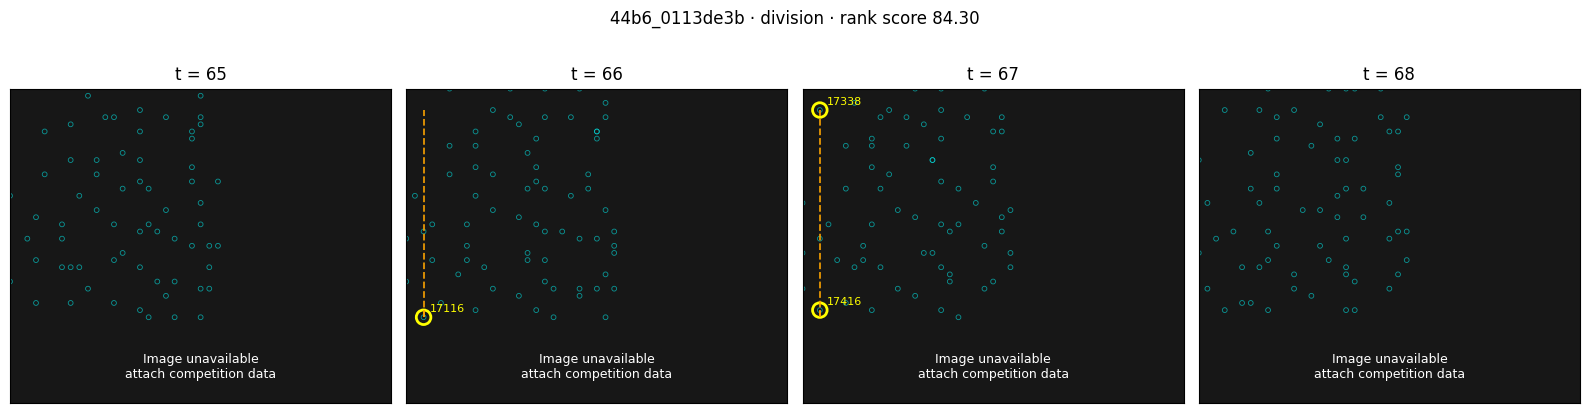

Raw image data was not found. Graph overlays and event tables remain available.


In [8]:
selected_candidates = events.loc[events.event_type.eq(EVENT_TYPE_TO_PLOT)].reset_index(drop=True)
if selected_candidates.empty:
    print(f"No {EVENT_TYPE_TO_PLOT!r} events found. Choose another event type in the configuration cell.")
else:
    selected_index = min(EVENT_RANK, len(selected_candidates) - 1)
    selected_event = selected_candidates.iloc[selected_index]
    display(selected_event[PUBLIC_EVENT_COLUMNS].to_frame("value"))
    plot_event(selected_event, graph_sets[PRIMARY_LABEL][str(selected_event.dataset)])

## 6. What to look for visually

- **True versus false divisions:** a true parent should plausibly give rise to two nearby daughters. Watch for a second child that is simply a neighbouring track.
- **Swapped identities:** two close tracks may cross and exchange successors even when both edge lengths look modest.
- **Long jumps:** decide whether the cell genuinely moved, the source/target localization is wrong, or the link crossed to another cell.
- **Missed detections:** a track ending before a gap and restarting afterward can produce fragmentation. A midpoint-like inserted node should coincide with visible signal.
- **Over-pruned short tracks:** many small components may represent real late arrivals, boundary cells, or temporarily faint cells—not just false positives.
- **Boundary cases:** tracks may correctly start or end at the spatial or temporal boundary. Do not treat every low-degree boundary node as an error.

Useful review practice is to inspect the highest-ranked events from **both** a candidate and a trusted baseline. The contrast helps separate dataset-intrinsic difficult regions from changes introduced by your method.

## 7. How to use this with your own submission

1. In the Kaggle notebook editor, attach the output of your tracking notebook—or a public/private dataset that contains `submission.csv`.
2. Copy its mounted path from the Data panel and set `SUBMISSION_PATH` in the configuration cell.
3. Attach the competition data as well if you want OME-Zarr image crops. The graph tables do not require it.
4. Choose thresholds and `EVENT_TYPE_TO_PLOT`, then **Run All**.
5. Review the compact tables first; change `EVENT_RANK` to step through individual plots.
6. To compare methods, add more CSV paths to `COMPARE_PATHS` and rerun.

Common pitfall: treating the ranking score as a confidence that the event is wrong. It is only a triage score. Confirm every decision against the images and its temporal context.

**Mini exercise:** pick one top-ranked long edge and one top-ranked division. Before viewing the images, write down what geometric feature triggered each flag. After viewing, label each as plausible, ambiguous, or likely wrong, and record the evidence. This simple audit log is often more informative than another global threshold sweep.

## 8. Extensions

This dependency-light review can be extended without changing the submission:

- add XZ/YZ projections for ambiguous depth assignments;
- compare the same event across two submissions in adjacent columns;
- export a small CSV of human labels for later error analysis;
- rank identity-swap candidates using crossing trajectories or velocity changes; or
- sample ordinary events alongside suspicious ones to estimate the review heuristic's selection bias.

The key principle is to keep graph diagnostics and image evidence together. Counts tell you where a method changed; crops help explain whether the change is biologically and temporally plausible.